### Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob as glob
import json, sys
import matplotlib.pyplot as plt
from pathlib import Path
import scienceplots

sys.path.append(str(Path.cwd().parents[0]))


from utils.notebook import format_metric, display_plot

In [3]:
## Helper functions
def load_data(folder_path : str, x_metric, y_metric : str, label : str = None, skip_x : bool = False):
    """
    Load data for a certain `metric` from an inputted `folder_path`.

    Input: folder_path, metric, label

    Return: {x, y, label (inputted, if needed for a plt legend)}
    """
    filenames = glob.glob(folder_path)

    len(filenames)

    x, y= [], []

    for filename in filenames:
        with open(filename, 'r') as file:
            data = json.load(file)
            if not skip_x:
                x.append(data['kwargs'][x_metric])
            else:
                x.append(1)
            if y_metric == "timeElapsedSec":
                y.append(data[y_metric])
            else:
                y.append(data['metrics'][y_metric])
    
    # open clean data too
    parent_folder = "/".join(folder_path.split("/")[0:-2])
    with open(f"{parent_folder}/clean.json", 'r') as file:
        clean_data = json.load(file)
        x.append(0)
        y.append(clean_data['wrapper'][y_metric])
    x, y = zip(*sorted(zip(x, y))) # order the data correctly
    return {'x': x, 'y': y, 'label': label}


def load_plot(folder : str, x_metric : str, y_metric : str, label : str, **styles):
    data = load_data(folder, x_metric = x_metric, y_metric = y_metric)
    plt.plot(data['x'], data['y'], label=label, **styles)


## Displaying Score vs. Epsilon

../attacks/fed/final_data/constpos/pgd/*
../attacks/fed/final_data/randpos/pgd/*
../attacks/fed/final_data/randspeed/pgd/*


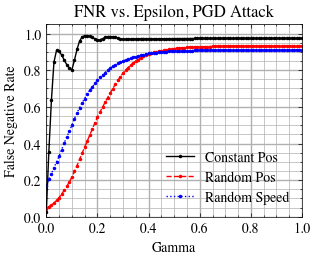

In [ ]:
## Load Plot for metric vs epsilon and different attack datasets
# Inputs
attack = "jsma"
x_metric = "gamma"
attack = "pgd"
x_metric = "eps"

y_metric = "falseNegativeRate"

# Load data
data = {}
folder_names = ["constpos", "randpos", "randspeed"]
legend_names = ["Constant Pos", "Random Pos", "Random Speed"]

plt.style.use(['science', 'ieee'])
plt.rcParams['text.usetex'] = False
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.dpi': '100'})

for folder in folder_names:
    # path = f"../defenses/fed/data-test/{folder}-clean/{attack}/*"
    path = f"../attacks/fed/final_data/{folder}/{attack}/*"
    print(path)
    data[folder] = load_data(path, x_metric = x_metric, y_metric = y_metric)
    plt.plot(data[folder]['x'], data[folder]['y'],
             marker="o", markersize=1.5,
             label = legend_names[folder_names.index(folder)])

# Plot the rest
display_metric  = format_metric(y_metric)
display_title = f"FNR vs. Epsilon, {attack.upper()} Attack"
in_x_metric = "Epsilon" if "eps" in x_metric else "Gamma"
display_plot(display_title, display_metric, x=(0, 1.0), y=(0.0, 1.05), x_metric = in_x_metric)

## Plot for adv trained

#### Irrelevant

31 31


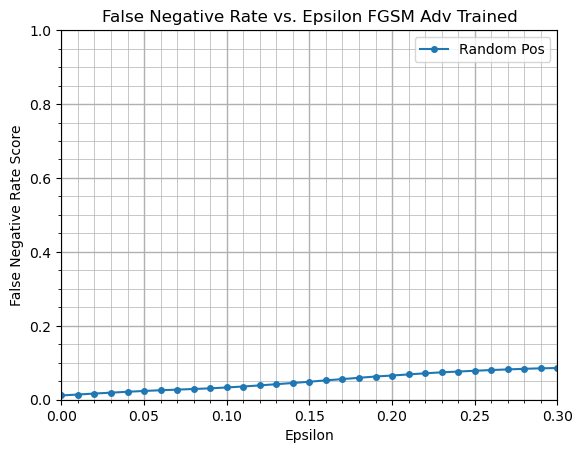

In [ ]:
## Load Plot for adv trained
# Inputs
attack = "fgsm"
x_metric = "eps"
y_metric = "falseNegativeRate"
folder = "randpos_pgd-0.05_epochs-5_trained-30-30-20"
# y_metric = "f1"

# Load data
data = {}
data["rpos"] = load_data(f"../defenses/fed/data-test/randpos-pgd-0.05-epochs-30/{attack}/*", 
                         x_metric = x_metric,
                         y_metric = y_metric)
# Plot Epsilon
plt.plot(data["rpos"]['x'], data["rpos"]['y'],
         marker="o", markersize=4, label = "Random Pos")

# Plot the rest
display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon FGSM Adv Trained"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 1))

51 51
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31


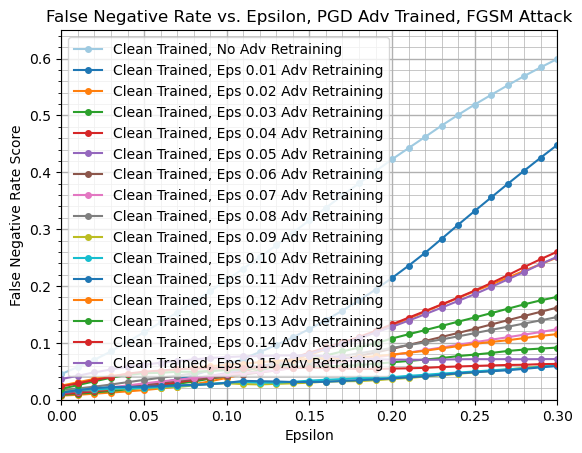

In [6]:
attack = "fgsm"
x_metric = "eps"
y_metric = "falseNegativeRate"

load_plot(
    folder=f"../attacks/fed/final_data/randpos/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "Clean Trained, No Adv Retraining",
    marker="o", linestyle="-", color="#9ECAE1"
)
for i in range(1, 16):
    eps = float(i/100)
    load_plot(
        folder=f"../defenses/fed/data-test/8-5-26/randpos_pgd-{eps:.2f}_epochs-5_clean/{attack}/*",
        x_metric = x_metric, y_metric = y_metric,
        label = f"Clean Trained, Eps {eps:.2f} Adv Retraining",
        marker="o", linestyle="-"
    )

display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 0.65))


#### Relevant

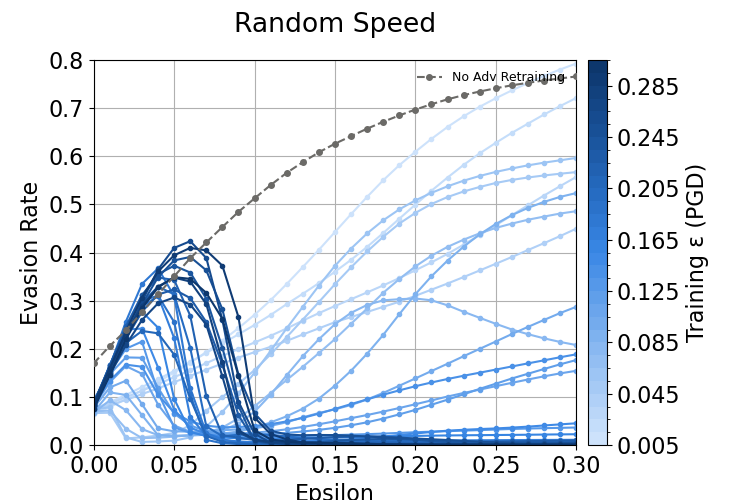

In [89]:
# Requires: pip install mplcursors ipympl
%matplotlib widget
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm, ListedColormap
import mplcursors
from utils.notebook import FilenameLoader

def plot_sweep (save_name, x_metric, y_metric, eps_values, y_lim, discrete_cbar : bool):
    attack = "fgsm"
    seq_cmap = LinearSegmentedColormap.from_list(
        "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
    )
    # eps_values = [0.08, 0.10, 0.12, 0.99]
    # Discrete bins, one per eps value, so each line's shade maps to exactly one
    # labeled colorbar tick instead of an interpolated position on a gradient.
    bounds = [v - 0.005 for v in eps_values] + [eps_values[-1] + 0.005]
    norm = BoundaryNorm(bounds, seq_cmap.N)

    fig, ax = plt.subplots(figsize=(7.5, 5))

    all_data = {"x": [], "y": []}
    # baseline = load_data(f"../attacks/fed/fed/final_data/randpos/{attack}/*",

    baseline = load_data(f"../attacks/fed/final_data/{save_name}/{attack}/*",
                        x_metric=x_metric, y_metric=y_metric)
    baseline_line, = ax.plot(baseline['x'], baseline['y'],
            marker="o", markersize=4, linestyle="--", color="#6b6a67",
            label="No Adv Retraining", zorder=3)
    all_data['x'].append(0)
    all_data['y'].append(baseline['y'][0])
    line_labels = {baseline_line: "No Adv Retraining"}


    for eps in eps_values:
        data = load_data(
            f"../defenses/fed/adv-test/{save_name}_targeted_{eps:.2f}/{attack}/*",
            x_metric=x_metric, y_metric=y_metric
        )

        all_data['x'].append(eps)
        all_data['y'].append(data['y'][0])

        # With only two lines, the lighter end of the colormap (#cde2fb) reads
        # as too pale against a white background - pick two fixed, more
        # contrasty positions on the colormap instead of the auto-spread ones.
        if len(eps_values) == 2:
            color = seq_cmap(0.45) if eps == eps_values[0] else seq_cmap(0.85)
        else:
            color = seq_cmap(norm(eps))

        line, = ax.plot(data['x'], data['y'],
                marker="o", markersize=3, linestyle="-",
                color=color, linewidth=1.5, zorder=2)
        line_labels[line] = f"Train \u03b5 = {eps:.2f}"

    if len(eps_values) == 2:
        cbar_cmap = ListedColormap([seq_cmap(0.45), seq_cmap(0.85)])
        sm = cm.ScalarMappable(cmap=cbar_cmap, norm=BoundaryNorm(bounds, cbar_cmap.N))
    else:
        sm = cm.ScalarMappable(cmap=seq_cmap, norm=norm)
    sm.set_array([])
    if discrete_cbar:
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, label="Training \u03b5 (PGD)", ticks=eps_values)
        cbar.ax.set_yticklabels([f"{v:.2f}" for v in eps_values])
    else:
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, label="Training \u03b5 (PGD)") # , ticks=eps_values

    ax.legend(loc="upper right", frameon=False, fontsize=9)
    ax.set_xlim(0, 0.3)
    ax.set_ylim(*y_lim)
    # display_metric = format_metric(y_metric)
    display_metric = "Evasion Rate"
    ax.set_xlabel("Epsilon")
    # ax.set_xlabel(format_metric(x_metric))
    ax.set_ylabel(f"{display_metric}")
    # ax.set_ylabel(f"{display_metric} Score")
    # ax.set_title(f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack", pad=20)
    ax.set_title(f"Random Speed", pad=20)
    ax.grid(True)

    # Hover tooltip: shows the exact training eps for whichever line is under the cursor.
    cursor = mplcursors.cursor(list(line_labels.keys()), hover=True) 

    @cursor.connect("add")
    def _on_hover(sel):
        label = line_labels[sel.artist]
        x_val, y_val = sel.target
        sel.annotation.set_text(f"{label}\n{x_metric} = {x_val:.2f}\n{y_metric} = {y_val:.3f}")
        sel.annotation.get_bbox_patch().set(fc="white", alpha=0.9)

    plt.show()

_, _, save_name, _ = FilenameLoader.rand_speed()
x_metric = "eps"

y_metric = "falseNegativeRate"
# y_lim = (0, 1.0)
# y_metric = "recall"
y_lim = (0., 0.8)

eps_values = [i / 100 for i in range(1, 31)]
discrete_cbar=False
# eps_values = [0.17, 0.18, 0.19]
# discrete_cbar=True
plt.rcParams.update({'font.size': 16})

plot_sweep(save_name, x_metric, y_metric, eps_values, y_lim, discrete_cbar)
# rand_pos = 0.18 - RUNNING
# rand_speed = 0.04?? - RUNNING
# const_pos = 0.01 ?????? - RUNNING

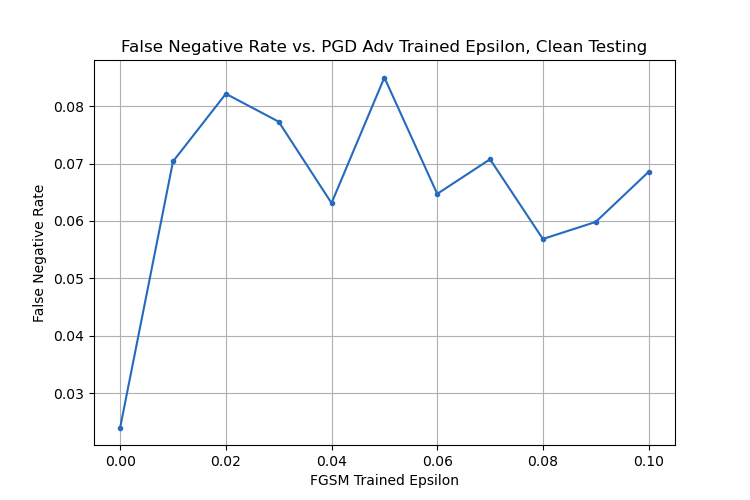

In [56]:
figure = plt.figure(figsize=(7.5, 5))

plt.plot(all_data['x'], all_data['y'], marker="o", markersize=3, linestyle="-", color="#256abf", linewidth=1.5, zorder=2)
plt.xlabel("FGSM Trained Epsilon")
plt.ylabel(format_metric(y_metric))
plt.title(f"{format_metric(y_metric)} vs. PGD Adv Trained Epsilon, Clean Testing")
plt.grid(True)
plt.show()

In [137]:
## Load Plot for adv trained
# Inputs
attack = "fgsm"
x_metric = "eps"
y_metric = "falseNegativeRate"
# y_metric = "f1"
folder = ""
# folder = "randpos-pgd-0.05-epochs-5"

# Load data

# clean
load_plot(
    folder=f"../attacks/fed/final_data/randpos/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "Clean Trained, No Adv Retraining",
    marker="o", linestyle="-", color="#4896C0"
)
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos-pgd-0.05-epochs-5/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "Clean Trained, 5 Epochs Retraining",
#     marker="s", linestyle="-", color="#4292C6"
# )
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos-pgd-0.05-epochs-30/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "Clean Trained, 30 Epochs Retraining",
#     marker="^", linestyle="-", color="#08519C"
# )

# 30/30/20
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos_trained-30-30-20_no-retraining/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "30/30/20 Adv Trained, No Adv Retraining",
#     marker="v", linestyle=":", color="#FD8D3C"
# )
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-5_trained-30-30-20/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "30/30/20 Adv Trained, 5 Epochs Retraining",
#     marker="D", linestyle=":", color="#E6550D"
# )
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-30_trained-30-30-20/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "30/30/20 Adv Trained, 30 Epochs Retraining",
#     marker="D", linestyle=":", color="#A63603"
# )

# 30/30/200

load_plot(
    folder=f"../defenses/fed/data-test/8-4-26/randpos_trained-30-30-20_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv General Trained",
    marker="D", linestyle=":", color="#c06fed"
)

load_plot(
    folder=f"../defenses/fed/data-test/8-4-26/randpos_trained-30-30-200_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv General Trained",
    marker="D", linestyle=":", color="#792ca2"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos-evasion_trained-5-5-5_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "5/5/5 Adv Evasion Trained",
    marker="^", linestyle="--", color="#ed6f6f"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos-evasion_trained-30-30-20_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Evasion Trained",
    marker="^", linestyle="--", color="#cb2929"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos-evasion_trained-30-30-200_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Evasion Trained",
    marker="^", linestyle="--", color="#651010"
)

# 7d32a8

display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 0.6))
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../defenses/fed/data-test/randpos-evasion_trained-5-5-5_no-retraining/clean.json'

51 51
31 31
31 31


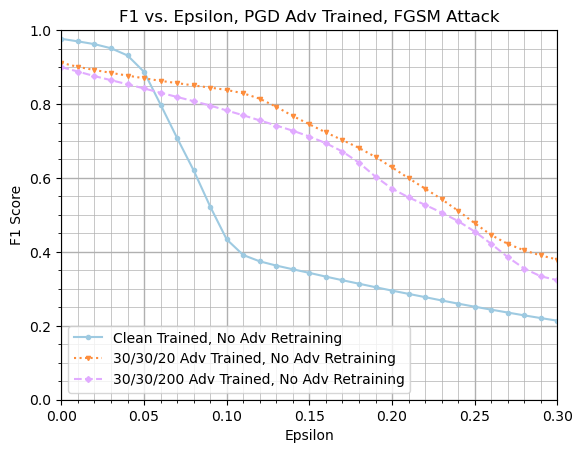

In [ ]:
## Load Plot for adv trained
# Inputs
attack = "fgsm"
x_metric = "eps"
# y_metric = "falseNegativeRate"
y_metric = "f1"
folder = ""
# folder = "randpos-pgd-0.05-epochs-5"


def load_plot(folder : str, x_metric : str, y_metric : str, label : str, marker : str = "o", linestyle : str = "-", color = None):
    data = load_data(folder, x_metric = x_metric, y_metric = y_metric)
    if color:
        plt.plot(data['x'], data['y'],
            marker=marker, markersize=3, label = label, linestyle=linestyle, color=color)
    else:
        plt.plot(data['x'], data['y'],
            marker=marker, markersize=4, label = label, linestyle=linestyle)


# Load data
load_plot(
    folder=f"../attacks/fed/final_data/randpos/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "Clean Trained, No Adv Retraining",
    marker="o", linestyle="-", color="#9ECAE1"
)
load_plot(
    folder=f"../defenses/fed/data-test/randpos_trained-30-30-20_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Trained, No Adv Retraining",
    marker="v", linestyle=":", color="#FD8D3C"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos_trained-30-30-200_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Trained, No Adv Retraining",
    marker="D", linestyle="--", color="#e1abff"
)


display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 1))

31 31
31 31
31 31
31 31
31 31
31 31


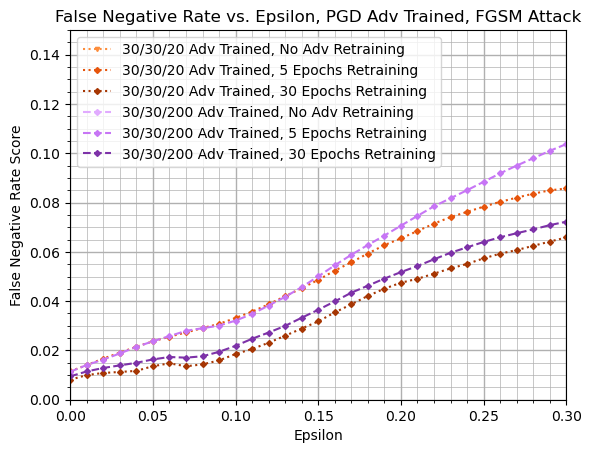

In [91]:
## Load Plot for adv trained
# Inputs
attack = "fgsm"
x_metric = "eps"
y_metric = "falseNegativeRate"
# y_metric = "f1"
folder = ""
# folder = "randpos-pgd-0.05-epochs-5"


def load_plot(folder : str, x_metric : str, y_metric : str, label : str, marker : str = "o", linestyle : str = "-", color = None):
    data = load_data(folder, x_metric = x_metric, y_metric = y_metric)
    if color:
        plt.plot(data['x'], data['y'],
            marker=marker, markersize=3, label = label, linestyle=linestyle, color=color)
    else:
        plt.plot(data['x'], data['y'],
            marker=marker, markersize=4, label = label, linestyle=linestyle)


# Load data

# 30/30/20
load_plot(
    folder=f"../defenses/fed/data-test/randpos_trained-30-30-20_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Trained, No Adv Retraining",
    marker="v", linestyle=":", color="#FD8D3C"
)
load_plot(
    folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-5_trained-30-30-20/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Trained, 5 Epochs Retraining",
    marker="D", linestyle=":", color="#E6550D"
)
load_plot(
    folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-30_trained-30-30-20/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Trained, 30 Epochs Retraining",
    marker="D", linestyle=":", color="#A63603"
)

# 30/30/200
load_plot(
    folder=f"../defenses/fed/data-test/randpos_trained-30-30-200_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Trained, No Adv Retraining",
    marker="D", linestyle="--", color="#e1abff"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-5_trained-30-30-200/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Trained, 5 Epochs Retraining",
    marker="D", linestyle="--", color="#c776f5"
)
load_plot(
    folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-30_trained-30-30-200/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Trained, 30 Epochs Retraining",
    marker="D", linestyle="--", color="#7d32a8"
)


# 7d32a8

display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 0.15))

## Graph for CW

In [19]:
## Load Plot for metric vs epsilon and different attack datasetsß
# Inputs
attack = "cw"
x_metric = ""
y_metric = "falseNegativeRate"
# y_metric = "f1"


# Load data
data = {}
folder_names = ["constpos", "randpos", "randspeed"]
legend_names = ["Constant Position", "Random Position", "Random Speed"]

# folder_names = ["constpos"]
# legend_names = ["Constant Position"]

for folder in folder_names:
    data[folder] = load_data(f"../attacks/fed/final_data/{folder}/{attack}/*", x_metric = x_metric, y_metric = y_metric, skip_x=True)

y_values = [v["y"][0] for v in data.values()]          # list of tuples, e.g. [(0.42,), (0.35,), (0.24,)]


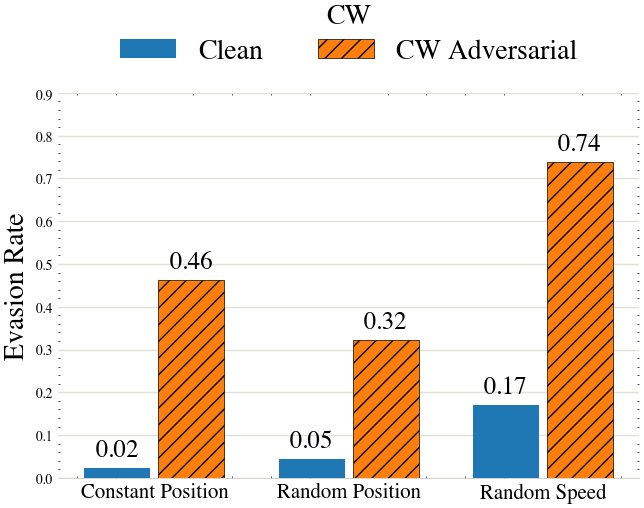

In [21]:
import numpy as np

# Match JSMA plot styling: default color cycle (blue/orange) + larger font

plt.style.use(['science', 'ieee'])
plt.rcParams['text.usetex'] = False
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.dpi': '100'})

display_names = {"randpos": "Random Position", "constpos": "Constant Position", "randspeed": "Random Speed"}
categories = list(data.keys())
labels = [display_names.get(c, c) for c in categories]

clean_vals = [data[c]["y"][0] for c in categories]
adv_vals   = [data[c]["y"][1] for c in categories]

x = np.arange(len(categories))
width = 0.34

fig, ax = plt.subplots(figsize=(7.5, 5))

# Matplotlib default color-cycle blue/orange - matches the JSMA line plot's palette
# Hatch lines are drawn using edgecolor, so the adversarial bars need a visible
# edgecolor for the hatch to actually render (facecolor alone isn't enough).
bars_clean = ax.bar(x - width/2 - 0.02, clean_vals, width, label="Clean", color="#1f77b4", edgecolor="none", zorder=3)
bars_adv   = ax.bar(x + width/2 + 0.02, adv_vals,   width, label="CW Adversarial", color="#ff7f0e", edgecolor="black", linewidth=0.5, hatch="//", zorder=3)

ax.bar_label(bars_clean, fmt="%.2f", padding=4, color="black", fontsize=18)
ax.bar_label(bars_adv,   fmt="%.2f", padding=4, color="black", fontsize=18)

ax.set_xticks(x)
ax.set_xticklabels(labels, color="black", fontsize=15)
ax.set_ylim(0, 0.9)
display_metric  = "Evasion Rate" # format_metric(y_metric)
ax.set_ylabel(display_metric, color="black", fontsize=20)
ax.set_title(f"CW",  color="black", pad=50, fontsize=20) # fontweight="bold",

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", colors="black", length=0)

# Recessive gridlines, no border box
ax.yaxis.grid(True, color="#e1e0d9", linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")

# Two series -> legend is required (identity isn't color-alone); placed above to avoid bar collisions
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2, frameon=False, labelcolor="black", fontsize=20)

plt.show()